# Example: Application of Time-Series Models to S&P 500 Exposure (SPY Returns)

Notebook 05 compared fixed empirical and parametric distributions with future returns. Here I ask whether modeling temporal dependence and changing volatility improves that description and its downside-risk predictions. The sequence is the same: observed data, fitted models, downside risk and out-of-sample evaluation.

The analysis uses Notebook 05’s adjusted SPY data and longer period: fit a mean model, inspect its residuals for ARCH effects, fit mean and variance jointly, check standardized residuals and forecast. Notebooks 06–07 provide the process foundations; Notebooks 08–10 provide the models and diagnostics. This notebook applies those tools rather than introducing new model classes.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import pacf
from arch import arch_model
from finstats.nonparametric import qq_data
from finstats.timeseries.diagnostics import acf, ljung_box, mcleod_li, standardized_residuals
from finstats.timeseries.volatility import garch11_unconditional_variance, garch11_forecast
from finstats.timeseries.forecasting import forecast_rmse, forecast_mae, forecast_mse

# Styling only; calculations use the library functions introduced earlier.
def dependence_panel(ax, values, title, nobs):
    ax.vlines(np.arange(len(values)),0,values,color="C0",linewidth=1.2)
    ax.axhline(0,color="0.6",linewidth=.8)
    bound = stats.norm.ppf(.975)/np.sqrt(nobs)
    ax.hlines([bound,-bound],.5,len(values)-.5,color="0.35",linestyle="--",linewidth=.9)
    ax.set(xlabel="Lag",ylabel="Sample correlation",title=title)
from statsmodels.tsa.stattools import adfuller
from arch.univariate import Normal, StudentsT
from finstats.risk import gaussian_var, gaussian_es, student_t_var, student_t_es
from pmdarima import auto_arima
from finstats.timeseries.joint import fit_arma_garch
from scipy.optimize import minimize_scalar
from finstats.timeseries.rolling import expanding_arma_garch_forecasts
from finance_statistical_methods.distributions.univariate import student_t
from finstats.risk import historical_var, historical_es

## 1. Data and Return Construction

I use the same saved adjusted SPY prices as Notebook 05. SPY provides S&P 500 exposure; adjusted prices account for distributions and corporate actions. Using a common dataset makes fixed and conditional model results directly comparable.

Daily simple returns are $R_t=100(P_t/P_{t-1}-1)$, in percentage points, and relative losses are $L_t=-R_t$. These are the same definitions used in Notebook 05. Dividends are not added again to adjusted prices.

### Training and Out-of-Sample Evaluation

Estimate and select models using 2017–2022 only, then evaluate on 2023–2025 using expanding-window one-step forecasts. Refit the selected model before every out-of-sample observation using the original training sample and all previously observed returns. Model orders and the Student-t assumption remain fixed. No future return enters its own forecast.

Prices: 2017-01-03–2025-12-31, n=2262
Training returns: 2017-01-04–2022-12-30, n=1509
Out-of-sample returns: 2023-01-03–2025-12-31, n=752


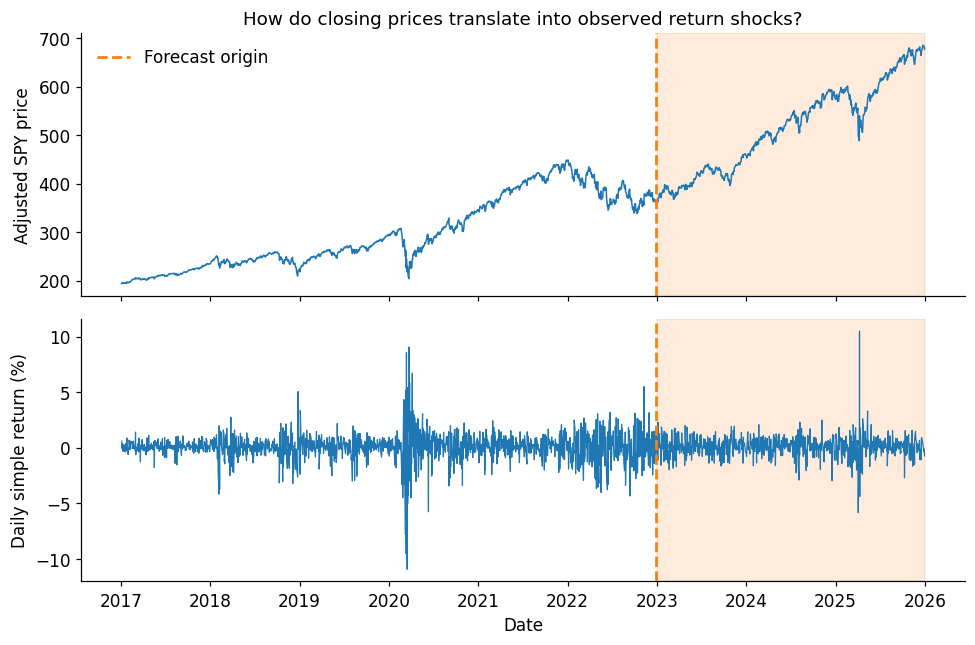

In [2]:
price_frame = pd.read_csv(repository / "data/spy_adjusted_prices_2017_2025.csv",parse_dates=["Date"])
assert price_frame.Date.is_monotonic_increasing and price_frame.Date.is_unique
assert np.isfinite(price_frame.AdjustedClose).all() and (price_frame.AdjustedClose>0).all()
prices = price_frame.set_index("Date").AdjustedClose
returns = (100*prices.pct_change(fill_method=None)).iloc[1:].rename("return")
assert np.isfinite(returns).all()
train = returns.loc[:"2022-12-31"]
test = returns.loc["2023-01-01":]
assert len(test)>700 and train.index.max()<test.index.min()
print(f"Prices: {prices.index.min().date()}–{prices.index.max().date()}, n={len(prices)}")
print(f"Training returns: {train.index.min().date()}–{train.index.max().date()}, n={len(train)}")
print(f"Out-of-sample returns: {test.index.min().date()}–{test.index.max().date()}, n={len(test)}")
fig, axes = plt.subplots(2,1,figsize=(9,6),sharex=True)
axes[0].plot(prices.index,prices,linewidth=1);axes[0].set(ylabel="Adjusted SPY price",title="How do closing prices translate into observed return shocks?")
axes[1].plot(returns.index,returns,linewidth=.8);axes[1].set(xlabel="Date",ylabel="Daily simple return (%)")
for ax in axes:
    ax.axvspan(test.index.min(),test.index.max(),color="C1",alpha=.15)
    ax.axvline(train.index.max(),color="C1",linestyle="--",label="Forecast origin")
axes[0].legend();fig.tight_layout();plt.show()

In [3]:
descriptive_table = pd.DataFrame([{"n":len(train),"mean (%)":sample_mean(train),"SD (%)":sample_standard_deviation(train),"skewness":sample_skewness(train),"raw kurtosis":sample_kurtosis(train)}])
display(descriptive_table.round(5))
train_mu, train_sd = sample_mean(train),sample_standard_deviation(train)


,n,mean (%),SD (%),skewness,raw kurtosis
0,1509,0.0499,1.25145,-0.57468,15.53046


### Test of Stationarity

The ADF test has a unit-root null. Rejecting it is evidence against a unit root under the specified test, not proof of stationarity or ergodicity. Log adjusted prices include an intercept and trend; returns include an intercept. The mean-model analysis below uses returns without additional differencing.

In [4]:
stationarity_rows = []
training_log_prices = np.log(prices.loc[:train.index.max()]).to_numpy()
for label, values, specification in (("Log price", training_log_prices, "ct"), ("Return", train.to_numpy(), "c")):
    statistic, p_value, used_lag, nobs, critical_values, _ = adfuller(values, regression=specification, autolag="AIC")
    stationarity_rows.append({"Series":label, "Deterministic terms":specification, "ADF statistic":statistic, "p-value":p_value, "Augmentation lags":used_lag, "Observations":nobs})
display(pd.DataFrame(stationarity_rows))

/var/folders/dw/9gkxwxn11d72y5z3d9f3n4200000gn/T/ipykernel_20143/3584293845.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  statistic, p_value, used_lag, nobs, critical_values, _ = adfuller(values, regression=specification, autolag="AIC")
/var/folders/dw/9gkxwxn11d72y5z3d9f3n4200000gn/T/ipykernel_20143/3584293845.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  sta

,Series,Deterministic terms,ADF statistic,p-value,Augmentation lags,Observations
0,Log price,ct,-2.560977,2.981756e-01,9,1500
1,Return,c,-12.025525,2.955195e-22,8,1500


## 2. Linear Time-Series Models

First select a conditional-mean specification, then examine what dependence remains in its residuals.

### Model Identification

The ACF and PACF both show early departures from zero, with the second lag close to the reference bounds. Neither has a clean cutoff that uniquely identifies an order. I compare ARMA(1,1), ARMA(1,2), ARMA(2,1) and ARMA(2,2) as a small candidate set, rather than claiming that two significant lags determine the model.

Dashed lines are approximate pointwise 95% white-noise reference bounds $\pm1.96/\sqrt{n}$. They are not simultaneous confidence bounds.

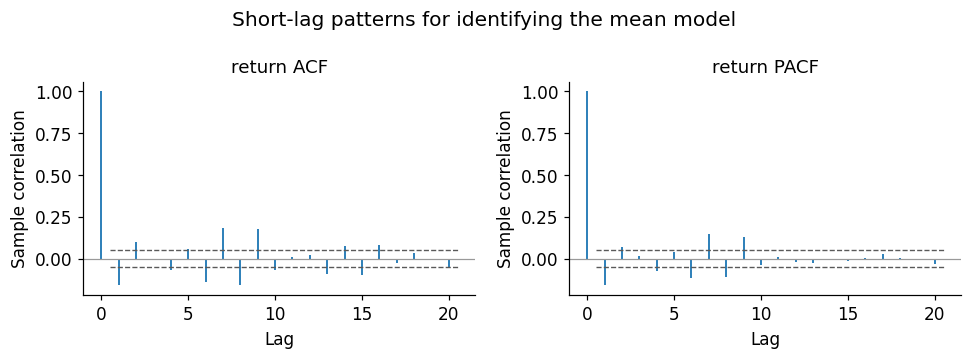

In [5]:
fig, axes = plt.subplots(1,2,figsize=(9,3.3))
dependence_panel(axes[0],acf(train,20),"return ACF",len(train))
dependence_panel(axes[1],pacf(train,nlags=20,method="ywm"),"return PACF",len(train))
fig.suptitle("Short-lag patterns for identifying the mean model")
fig.tight_layout();plt.show()

### Model Comparison and Evaluation

Compare candidate specifications on common observations, using coefficient uncertainty and likelihood criteria together.

#### Coefficients and AIC/BIC

Fit all four models by Gaussian maximum likelihood on the same observations. Sandwich standard errors account for the working likelihood’s variance misspecification under suitable assumptions. The table reports estimates, p-values and significance at 10%, 5% and 1%. Significance is approximate and conditional on the specification; it is not itself a model-selection rule.

AIC and BIC penalize additional parameters. BIC is the prespecified selection criterion. Each model is checked from its default and a neutral start, retaining the converged fit with the higher likelihood.

In [6]:
mean_models = {}
mean_start_records = []
coefficient_rows = []
for p,q in [(1,1),(1,2),(2,1),(2,2)]:
    model = ARIMA(train.to_numpy(),order=(p,0,q),trend="c")
    neutral_start = np.r_[train.mean(),np.zeros(p+q),train.var()]
    fits = []
    for label,start in [("Default",None),("Neutral",neutral_start)]:
        fit = model.fit(start_params=start,cov_type="robust",method_kwargs={"maxiter":500})
        converged = fit.mle_retvals.get("converged",True)
        mean_start_records.append({"Model":f"ARMA({p},{q})","Start":label,
                                   "Converged":converged,"Log-likelihood":fit.llf})
        if converged and np.isfinite(fit.llf): fits.append(fit)
    if not fits: raise RuntimeError(f"No converged ARMA({p},{q}) estimate")
    fit = max(fits,key=lambda fit:fit.llf)
    mean_models[p,q] = fit
    for name,estimate,se,pvalue in zip(fit.param_names,fit.params,fit.bse,fit.pvalues):
        if name != "sigma2":
            coefficient_rows.append({"Model":f"ARMA({p},{q})","Parameter":name,
                "Estimate":estimate,"Robust SE":se,"p-value":pvalue,
                **{f"Significant at {level:.0%}": "Yes" if pvalue < level else "No"
                   for level in (.10,.05,.01)}})
display(pd.DataFrame(coefficient_rows).set_index(["Model","Parameter"]).round(4))
mean_comparison = pd.DataFrame([{"Model":f"ARMA({p},{q})","n":fit.nobs,
    "Log-likelihood":fit.llf,"AIC":fit.aic,"BIC":fit.bic} for (p,q),fit in mean_models.items()])
display(mean_comparison.set_index("Model").round(3))
print("Converged preliminary fits:",sum(row["Converged"] for row in mean_start_records),"of",len(mean_start_records))
selected_p,selected_q = min(mean_models,key=lambda order:mean_models[order].bic)
mean_fit = mean_models[selected_p,selected_q]
print(f"BIC-selected mean: ARMA({selected_p},{selected_q})")

Estimate  Robust SE  p-value Significant at 10%  \
Model     Parameter                                                    
ARMA(1,1) const        0.0499     0.0282   0.0765                Yes   
          ar.L1       -0.4048     0.3613   0.2625                 No   
          ma.L1        0.2469     0.3775   0.5131                 No   
ARMA(1,2) const        0.0500     0.0299   0.0944                Yes   
          ar.L1       -0.1577     0.5474   0.7732                 No   
          ma.L1        0.0095     0.5507   0.9862                 No   
          ma.L2        0.0824     0.0931   0.3761                 No   
ARMA(2,1) const        0.0500     0.0296   0.0916                Yes   
          ar.L1       -0.0788     0.8124   0.9227                 No   
          ar.L2        0.0840     0.1344   0.5322                 No   
          ma.L1       -0.0702     0.8196   0.9317                 No   
ARMA(2,2) const        0.0500     0.0287   0.0816                Yes   
          ar.L1       -1.7398     0.0573   0.0000                Yes   
          ar.L2       -0.8752     0.0567   0.0000                Yes   
          ma.L1        1.6335     0.0857   0.0000                Yes   
          ma.L2        0.7376     0.0880   0.0000                Yes   

                    Significant at 5% Significant at 1%  
Model     Parameter                                      
ARMA(1,1) const                    No                No  
          ar.L1                    No                No  
          ma.L1                    No                No  
ARMA(1,2) const                    No                No  
          ar.L1                    No                No  
          ma.L1                    No                No  
          ma.L2                    No                No  
ARMA(2,1) const                    No                No  
          ar.L1                    No                No  
          ar.L2                    No                No  
          ma.L1                    No                No  
ARMA(2,2) const                    No                No  
          ar.L1                   Yes               Yes  
          ar.L2                   Yes               Yes  
          ma.L1                   Yes               Yes  
          ma.L2                   Yes               Yes

,n,Log-likelihood,AIC,BIC
Model,,,,
"ARMA(1,1)",1509,-2456.974,4921.948,4943.225
"ARMA(1,2)",1509,-2454.829,4919.658,4946.254
"ARMA(2,1)",1509,-2455.476,4920.952,4947.548
"ARMA(2,2)",1509,-2410.357,4832.714,4864.629


Converged preliminary fits: 8 of 8
BIC-selected mean: ARMA(2,2)


ARMA(1,1) is the parsimonious reference, but its individual dynamic coefficients are imprecise. ARMA(1,2) and ARMA(2,1) improve likelihood only slightly and are penalized by BIC. ARMA(2,2) has a substantially lower AIC/BIC, and its four dynamic coefficients are significant under the reported approximation. Its opposing AR and MA coefficients still warrant caution about cancellation and interpretation.

#### Automatic ARIMA

A bounded nonseasonal automatic search covers AR and MA orders 0–2, with differencing fixed at zero and an intercept included. It uses the same sample and BIC, so it is a supporting cross-check rather than independent evidence.

In [7]:
automatic_fit = auto_arima(train.to_numpy(),d=0,seasonal=False,start_p=0,start_q=0,
    max_p=2,max_q=2,max_order=4,with_intercept=True,information_criterion="bic",
    stepwise=False,suppress_warnings=True,error_action="raise",maxiter=500)
print("Automatic BIC cross-check:",automatic_fit.order)
print(f"AIC={automatic_fit.aic():.3f}; BIC={automatic_fit.bic():.3f}")
assert automatic_fit.order[1] == 0

Automatic BIC cross-check: (2, 0, 2)
AIC=4832.714; BIC=4864.629


### Residual Diagnostics

Check the selected mean model for dependence in both residuals and squared residuals. Divide residuals by their fitted constant innovation SD: this constant scaling does not change either ACF. It differs from the joint model’s time-varying standardization below.

Ljung–Box assesses remaining linear dependence; McLeod–Li applies a Ljung–Box-type check to squared residuals for remaining magnitude dependence. Their reference p-values are approximate, particularly when the mean model omits conditional heteroskedasticity.

,Check,statistic,p_value,df,lags,nobs
0,Residual Ljung–Box,16.64804,0.01067,6,10,1507
1,Squared residual McLeod–Li,1763.00788,0.00000,10,10,1507
2,Residual Ljung–Box,26.14556,0.05201,16,20,1507
3,Squared residual McLeod–Li,2100.96577,0.00000,20,20,1507


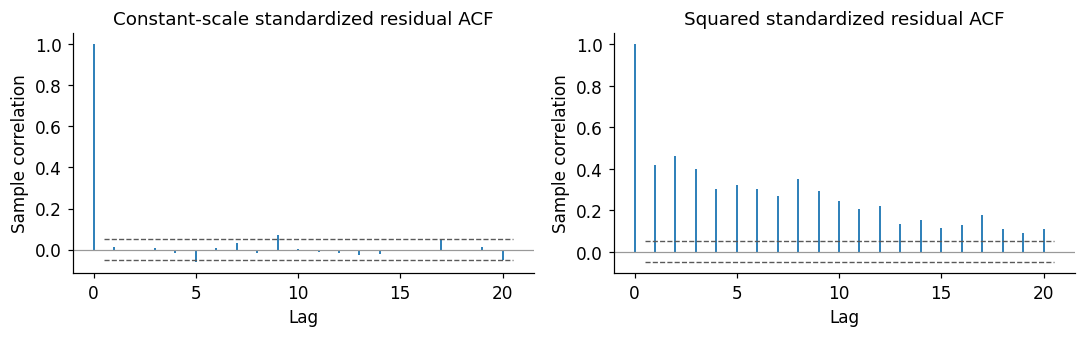

In [8]:
mean_residuals = np.asarray(mean_fit.resid)[2:]
mean_innovation_sd = np.sqrt(float(dict(zip(mean_fit.param_names,mean_fit.params))["sigma2"]))
mean_standardized = mean_residuals/mean_innovation_sd
mean_diagnostics = []
for h in [10,20]:
    mean_diagnostics.append({"Check":"Residual Ljung–Box",**ljung_box(mean_standardized,h,model_df=selected_p+selected_q)})
    mean_diagnostics.append({"Check":"Squared residual McLeod–Li",**mcleod_li(mean_standardized,h)})
display(pd.DataFrame(mean_diagnostics).round(5))
fig, axes = plt.subplots(1,2,figsize=(10,3.2))
dependence_panel(axes[0],acf(mean_standardized,20),"Constant-scale standardized residual ACF",len(mean_standardized))
dependence_panel(axes[1],acf(mean_standardized**2,20),"Squared standardized residual ACF",len(mean_standardized))
fig.tight_layout();plt.show()

### Conclusion

Both AIC/BIC and the automatic cross-check favor ARMA(2,2). I carry that mean order forward. Residual diagnostics are mixed: Ljung–Box rejects at lag 10 but is just above 5% at lag 20. The initial mean fit is therefore provisional rather than fully validated; the joint model’s standardized residuals must be checked after accounting for changing volatility.

## 3. Extending to Conditional Volatility

Retain the selected mean order and assess whether changing innovation variance is needed.

### Model Identification

Dependence in squared mean-model residuals indicates that a constant innovation variance may be inadequate. A slowly decaying squared-residual ACF can require many lags in an ARCH model, motivating a more parsimonious GARCH specification. The McLeod–Li test screens for this magnitude dependence; it does not identify an exact GARCH order, and its conventional reference requires suitable moments.

Unlike simple AR/MA cutoff patterns, squared-residual plots do not reliably distinguish GARCH orders. I compare GARCH(1,1), GARCH(2,1), GARCH(1,2) and GARCH(2,2). As in Notebook 09, p counts variance lags and q counts squared-innovation lags; the Python `arch` package reverses these names.

### Model Comparison and Evaluation

Compare candidate specifications on common observations, using coefficient uncertainty and likelihood criteria together.

#### Coefficients and AIC/BIC

Use a common Gaussian working likelihood to compare the four variance specifications. The ARMA(2,2) order is held fixed, while all mean and volatility coefficients are jointly re-estimated for each candidate. BIC selects the variance order; AIC and the nominal coefficient-significance results provide complementary information.

All candidates use the same conditional-likelihood initialization and discard two initial observations. Presample centered observations and innovations are zero; variance and missing presample squared-innovation/variance terms use the first 75 observations’ variance. Three starts are checked per model. The bounded grid is the automatic comparison, without a separate auto-GARCH cross-check.

Near-zero coefficients or near-unit persistence make ordinary Wald inference nonregular. Such fits are flagged; unstable curvature is marked unavailable. These significance labels do not replace information criteria and residual diagnostics.

In [9]:
garch_models = {}
garch_rows = []
garch_coefficient_rows = []
for order in [(1,1),(2,1),(1,2),(2,2)]:
    fit = fit_arma_garch(train.to_numpy(),mean_fit.arparams,mean_fit.maparams,
        mean_fit.params[0],distribution="normal",hold_back=2,n_starts=3,
        seed=111,garch_order=order)
    garch_models[order,"normal"] = fit
    for name,estimate in fit.params.items():
        if name != "omega" and not name.startswith(("alpha[","beta[")): continue
        inference = fit.inference[name]
        pvalue = inference["p_value"]
        row = {"Variance model":f"GARCH{order}","Parameter":name,"Estimate":estimate,
               "Robust SE":inference["standard_error"],"p-value":pvalue}
        for level in (.10,.05,.01):
            row[f"Significant at {level:.0%}"] = ("Unavailable" if not np.isfinite(pvalue)
                                                  else "Yes" if pvalue<level else "No")
        row["Inference"] = ("Boundary approximation" if inference["status"].startswith("Nominal") else
                            "Unavailable" if inference["status"].startswith("Unavailable") else "Regular approximation")
        garch_coefficient_rows.append(row)
    garch_rows.append({"Variance model":f"GARCH{order}","n":fit.nobs,
        "Parameters":len(fit.params),"Log-likelihood":fit.loglikelihood,"AIC":fit.aic,
        "BIC":fit.bic,"Persistence":np.sum(fit.alpha)+np.sum(fit.beta),
        "Converged starts":sum(record["converged"] for record in fit.starts)})
display(pd.DataFrame(garch_coefficient_rows).set_index(["Variance model","Parameter"]).round(4))
garch_comparison = pd.DataFrame(garch_rows).set_index("Variance model")
display(garch_comparison.round(4))
selected_order = min([key[0] for key in garch_models],key=lambda order:garch_models[order,"normal"].bic)
gaussian_fit = garch_models[selected_order,"normal"]
print(f"Gaussian working-likelihood selection: GARCH{selected_order}")

Estimate  Robust SE  p-value Significant at 10%  \
Variance model Parameter                                                    
GARCH(1, 1)    omega        0.0291     0.0094   0.0020                Yes   
               alpha[1]     0.2304     0.0484   0.0000                Yes   
               beta[1]      0.7695     0.0369   0.0000                Yes   
GARCH(2, 1)    omega        0.0291     0.0107   0.0063                Yes   
               alpha[1]     0.2304     0.0777   0.0030                Yes   
               beta[1]      0.7694     0.4697   0.1014                 No   
               beta[2]      0.0001     0.4076   0.9998                 No   
GARCH(1, 2)    omega        0.0311     0.0121   0.0103                Yes   
               alpha[1]     0.2151     0.0639   0.0008                Yes   
               alpha[2]     0.0233     0.0823   0.7771                 No   
               beta[1]      0.7593     0.0542   0.0000                Yes   
GARCH(2, 2)    omega        0.0547     0.0178   0.0021                Yes   
               alpha[1]     0.2125     0.0559   0.0001                Yes   
               alpha[2]     0.1838     0.0566   0.0012                Yes   
               beta[1]      0.0431     0.1012   0.6699                 No   
               beta[2]      0.5512     0.0771   0.0000                Yes   

                         Significant at 5% Significant at 1%  \
Variance model Parameter                                       
GARCH(1, 1)    omega                   Yes               Yes   
               alpha[1]                Yes               Yes   
               beta[1]                 Yes               Yes   
GARCH(2, 1)    omega                   Yes               Yes   
               alpha[1]                Yes               Yes   
               beta[1]                  No                No   
               beta[2]                  No                No   
GARCH(1, 2)    omega                   Yes                No   
               alpha[1]                Yes               Yes   
               alpha[2]                 No                No   
               beta[1]                 Yes               Yes   
GARCH(2, 2)    omega                   Yes               Yes   
               alpha[1]                Yes               Yes   
               alpha[2]                Yes               Yes   
               beta[1]                  No                No   
               beta[2]                 Yes               Yes   

                                       Inference  
Variance model Parameter                          
GARCH(1, 1)    omega       Regular approximation  
               alpha[1]    Regular approximation  
               beta[1]     Regular approximation  
GARCH(2, 1)    omega      Boundary approximation  
               alpha[1]   Boundary approximation  
               beta[1]    Boundary approximation  
               beta[2]    Boundary approximation  
GARCH(1, 2)    omega       Regular approximation  
               alpha[1]    Regular approximation  
               alpha[2]    Regular approximation  
               beta[1]     Regular approximation  
GARCH(2, 2)    omega       Regular approximation  
               alpha[1]    Regular approximation  
               alpha[2]    Regular approximation  
               beta[1]     Regular approximation  
               beta[2]     Regular approximation

,n,Parameters,Log-likelihood,AIC,BIC,Persistence,Converged starts
Variance model,,,,,,,
"GARCH(1, 1)",1507,8,-1979.7971,3975.5943,4018.1373,0.9999,3
"GARCH(2, 1)",1507,9,-1979.7975,3977.5951,4025.4560,0.9999,3
"GARCH(1, 2)",1507,9,-1979.6755,3977.3510,4025.2119,0.9977,3
"GARCH(2, 2)",1507,10,-1979.2892,3978.5785,4031.7572,0.9907,3


Gaussian working-likelihood selection: GARCH(1, 1)


GARCH(1,1) has the lowest Gaussian AIC and BIC. The larger specifications improve likelihood too little to offset their parameter penalties, and the one-lag extensions contain imprecise added coefficients. I retain GARCH(1,1) for the diagnostic stage.

### Residual Diagnostics

Check the fitted model’s remaining temporal dependence and its assumed innovation distribution.

#### Residual Diagnostics and QQ Plots

Check the selected Gaussian model’s standardized residuals and their squares. Neither lag-20 test rejects in this sample, supporting the fitted dynamics without proving IID innovations.

The QQ panels compare the same standardized residuals with Gaussian and unit-variance Student-t references. The Student-t degrees of freedom are fitted only for this diagnostic. Tail departures from the Gaussian reference motivate a density change even when the temporal diagnostics look satisfactory.

For this diagnostic reference, location is fixed at zero and variance at one. Numerical maximum likelihood estimates only degrees of freedom, with Student-t scale $\sqrt{(\nu-2)/\nu}$. Both QQ panels use the same horizontal and vertical limits and equal aspect. This reference fit is separate from the subsequent joint Student-t refit of all mean and variance parameters.

,statistic,p_value,df,lags,nobs
Series,,,,,
Gaussian standardized residuals,10.84142,0.81917,16,20,1507
Gaussian squared standardized residuals,12.23761,0.90765,20,20,1507


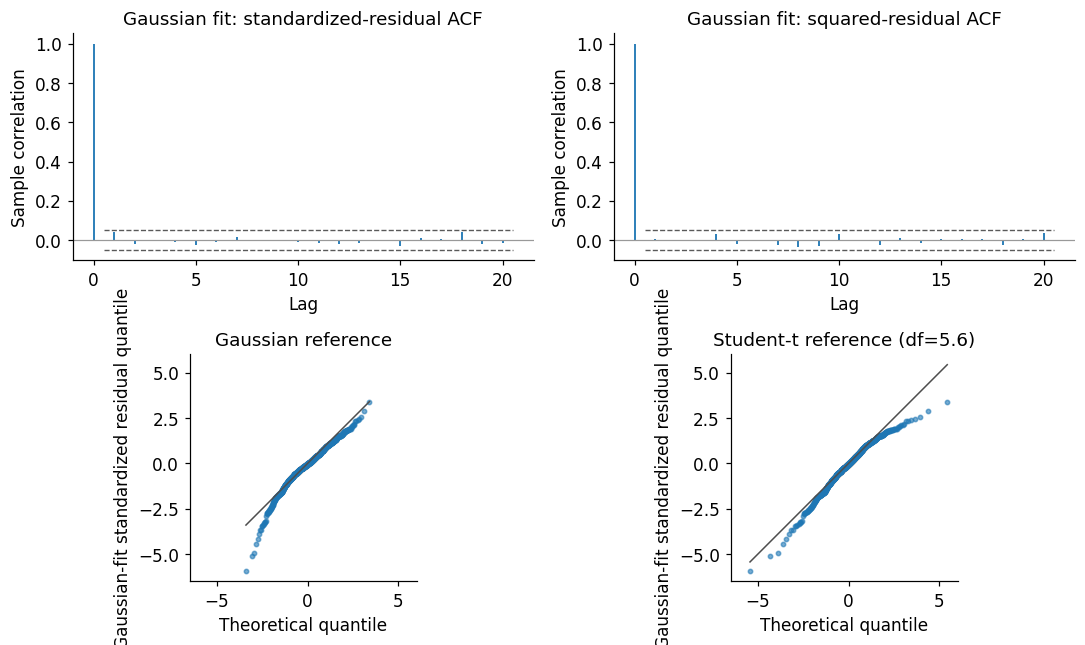

In [10]:
_,gaussian_residuals,gaussian_variances = gaussian_fit.filter()
gaussian_standardized = (gaussian_residuals/np.sqrt(gaussian_variances))[2:]
display(pd.DataFrame([
    {"Series":"Gaussian standardized residuals",**ljung_box(gaussian_standardized,20,model_df=selected_p+selected_q)},
    {"Series":"Gaussian squared standardized residuals",**mcleod_li(gaussian_standardized,20)}
]).set_index("Series").round(5))
# Fit a unit-variance Student-t reference to the Gaussian fit's standardized residuals.
def diagnostic_t_objective(df):
    return -stats.t.logpdf(gaussian_standardized,df,scale=np.sqrt((df-2)/df)).sum()
diagnostic_t_fit = minimize_scalar(diagnostic_t_objective,bounds=(2.05,200),method="bounded")
assert diagnostic_t_fit.success
diagnostic_df = float(diagnostic_t_fit.x)
fig, axes = plt.subplots(2,2,figsize=(10,6))
dependence_panel(axes[0,0],acf(gaussian_standardized,20),"Gaussian fit: standardized-residual ACF",len(gaussian_standardized))
dependence_panel(axes[0,1],acf(gaussian_standardized**2,20),"Gaussian fit: squared-residual ACF",len(gaussian_standardized))
qq_coordinates = []
for ax,label,distribution in [(axes[1,0],"Gaussian reference",stats.norm),
    (axes[1,1],f"Student-t reference (df={diagnostic_df:.1f})",
     stats.t(diagnostic_df,scale=np.sqrt((diagnostic_df-2)/diagnostic_df)))]:
    theoretical,observed = qq_data(gaussian_standardized,distribution)
    qq_coordinates.extend([theoretical,observed])
    ax.scatter(theoretical,observed,s=8,alpha=.6)
    ax.plot(theoretical,theoretical,color="0.3",linewidth=1)
    ax.set(xlabel="Theoretical quantile",ylabel="Gaussian-fit standardized residual quantile",title=label)
qq_min = min(np.min(v) for v in qq_coordinates)
qq_max = max(np.max(v) for v in qq_coordinates)
qq_pad = .05*(qq_max-qq_min)
for ax in axes[1]:
    ax.set_xlim(qq_min-qq_pad,qq_max+qq_pad)
    ax.set_ylim(qq_min-qq_pad,qq_max+qq_pad)
    ax.set_aspect("equal",adjustable="box")
fig.tight_layout();plt.show()

#### Student-t Refit and Comparison

Keep ARMA(2,2)–GARCH(1,1), refit all parameters jointly with Student-t innovations, and compare it with the Gaussian fit using the same observations and initialization. AIC/BIC assess whether the improved density compensates for the additional parameter. Repeat standardized-residual checks for the selected fit.

In [11]:
student_fit = fit_arma_garch(train.to_numpy(),mean_fit.arparams,mean_fit.maparams,
    mean_fit.params[0],distribution="t",hold_back=2,n_starts=3,seed=111,garch_order=selected_order)
garch_models[selected_order,"t"] = student_fit
innovation_comparison = pd.DataFrame([{"Innovations":label,"n":fit.nobs,
    "Parameters":len(fit.params),"Log-likelihood":fit.loglikelihood,"AIC":fit.aic,
    "BIC":fit.bic,"df":fit.df} for label,fit in [("Gaussian",gaussian_fit),("Student-t",student_fit)]])
display(innovation_comparison.set_index("Innovations").round(4))
selected_density = min(["normal","t"],key=lambda density:garch_models[selected_order,density].bic)
final_fit = garch_models[selected_order,selected_density]
final_label = "Student-t" if selected_density=="t" else "Gaussian"
print(f"Final staged selection: ARMA({selected_p},{selected_q})–GARCH{selected_order}, {final_label} innovations")


,n,Parameters,Log-likelihood,AIC,BIC,df
Innovations,,,,,,
Gaussian,1507,8,-1979.7971,3975.5943,4018.1373,NaN
Student-t,1507,9,-1927.2861,3872.5721,3920.4330,5.7188


Final staged selection: ARMA(2,2)–GARCH(1, 1), Student-t innovations


In [12]:
fitted_mean,final_residuals,final_variances = final_fit.filter()
fitted_sd = np.sqrt(final_variances)
final_standardized = (final_residuals/fitted_sd)[2:]
final_df = final_fit.df if final_fit.df is not None else np.inf
final_diagnostic_rows = []
for h in [10,20]:
    final_diagnostic_rows.append({"Series":"Standardized",**ljung_box(final_standardized,h,model_df=selected_p+selected_q)})
    squared_screen = mcleod_li(final_standardized,h)
    if final_df<=4: squared_screen["p_value"]=np.nan
    final_diagnostic_rows.append({"Series":"Squared standardized",**squared_screen})
display(pd.DataFrame(final_diagnostic_rows).round(5))
if final_df<=4: print("Squared-screen p-values omitted: fitted innovations have no finite fourth moment.")
final_params = final_fit.params
omega_hat,alpha_hat,beta_hat = final_fit.omega,final_fit.alpha,final_fit.beta
final_persistence = np.sum(alpha_hat)+np.sum(beta_hat)
final_long_run = omega_hat/(1-final_persistence) if final_persistence<1-1e-6 else np.nan
display(pd.Series(final_params,name="Joint conditional-MLE estimate").to_frame().round(5))
print(f"Selected volatility persistence: {final_persistence:.6f}")
if not np.isfinite(final_long_run): print("No reliable stationary long-run variance at the unit-persistence boundary.")


,Series,statistic,p_value,df,lags,nobs
0,Standardized,2.81382,0.83183,6,10,1507
1,Squared standardized,9.18990,0.51418,10,10,1507
2,Standardized,8.27215,0.94035,16,20,1507
3,Squared standardized,12.98649,0.87796,20,20,1507


,Joint conditional-MLE estimate
mu,0.10648
ar[1],-1.73899
ar[2],-0.84901
ma[1],1.69876
ma[2],0.80308
omega,0.01689
alpha[1],0.18072
beta[1],0.81928
nu,5.71880


Selected volatility persistence: 1.000000
No reliable stationary long-run variance at the unit-persistence boundary.


### Conclusion

Student-t has lower AIC and BIC, so the final specification is **ARMA(2,2)–GARCH(1,1) with Student-t innovations**. The mean order, variance order and density have been assessed in sequence. Volatility persistence remains near one, so a reliable stationary long-run variance is not reported. In-sample improvement still requires out-of-sample evaluation.

## 4. Model Evaluation

Distinguish retrospective fitted descriptions from forecasts evaluated on future observations.

### In-Sample

Compare fitted conditional expectations with observed returns, then examine changing conditional uncertainty and 5% VaR/ES. The conditional mean need not track each realized return; conditional variance describes uncertainty rather than an observed quantity.

Loss is negative simple return, as in Notebook 05. Student-t SD is converted to scale before using the earlier risk formulas. Negative VaR and ES are drawn on the return axis. Parameters use the full estimation sample, so these plots are retrospective fitted descriptions, not out-of-sample forecasts.

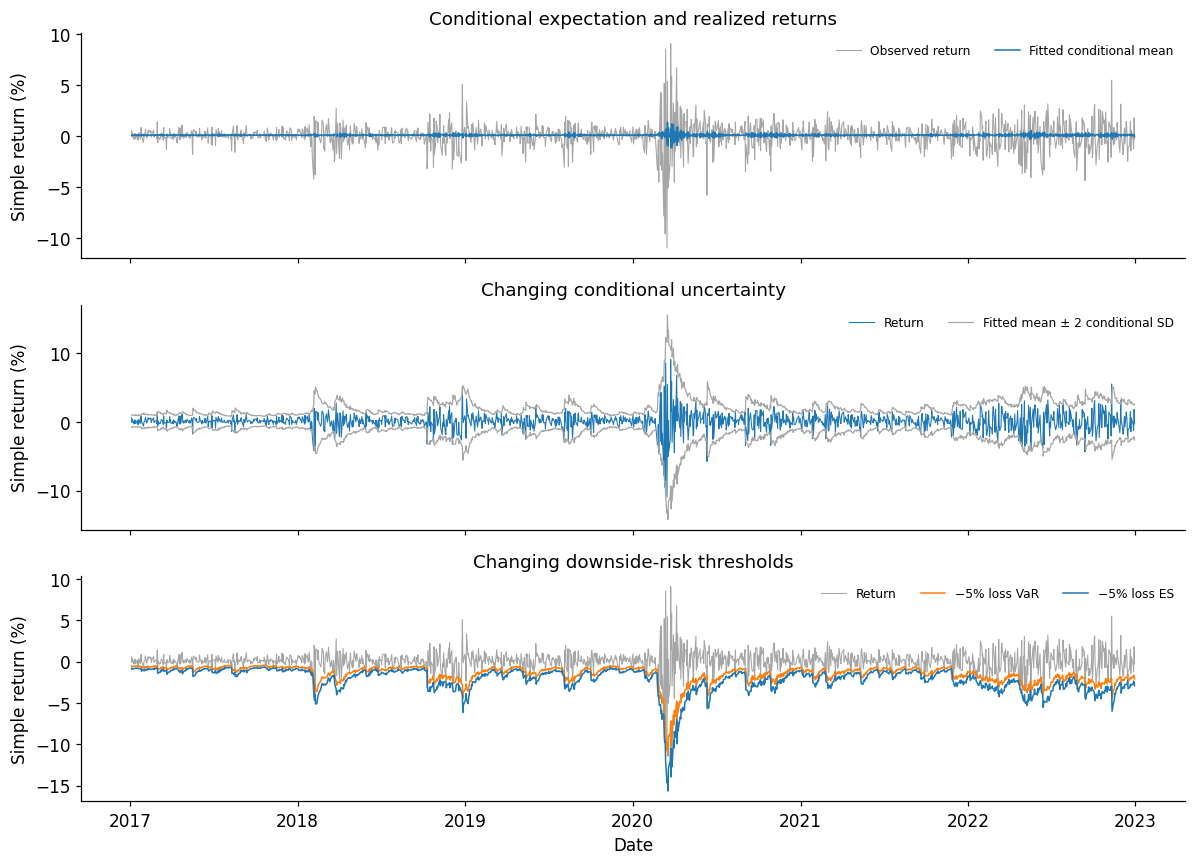

In [13]:
def conditional_loss_risk(mean, sd):
    if final_label == "Student-t":
        nu = float(final_params["nu"])
        scale = sd*np.sqrt((nu-2)/nu)
        return student_t_var(-mean,scale,nu,.05), student_t_es(-mean,scale,nu,.05)
    return gaussian_var(-mean,sd,.05), gaussian_es(-mean,sd,.05)

fitted_mean, _, fitted_variance = final_fit.filter()
fitted_sd = np.sqrt(fitted_variance)
fitted_risk = np.array([conditional_loss_risk(m,s) if np.isfinite(m+s) else (np.nan,np.nan)
                        for m,s in zip(fitted_mean,fitted_sd)])
fig, axes = plt.subplots(3,1,figsize=(11,8),sharex=True)
axes[0].plot(train.index,train,color="0.65",linewidth=.7,label="Observed return")
axes[0].plot(train.index,fitted_mean,color="C0",linewidth=1,label="Fitted conditional mean")
axes[0].set(ylabel="Simple return (%)",title="Conditional expectation and realized returns")
axes[1].plot(train.index,train,color="C0",linewidth=.7,label="Return")
axes[1].plot(train.index,fitted_mean+2*fitted_sd,color="0.65",linewidth=.8,label="Fitted mean ± 2 conditional SD")
axes[1].plot(train.index,fitted_mean-2*fitted_sd,color="0.65",linewidth=.8)
axes[1].set(ylabel="Simple return (%)",title="Changing conditional uncertainty")
axes[2].plot(train.index,train,color="0.65",linewidth=.7,label="Return")
axes[2].plot(train.index,-fitted_risk[:,0],color="C1",linewidth=1,label="−5% loss VaR")
axes[2].plot(train.index,-fitted_risk[:,1],color="C0",linewidth=1,label="−5% loss ES")
axes[2].set(xlabel="Date",ylabel="Simple return (%)",title="Changing downside-risk thresholds")
for ax in axes: ax.legend(fontsize=8,ncol=3)
fig.tight_layout();plt.show()

### Out-of-Sample

Evaluate predictions using observations excluded from each fit, keeping mean accuracy and downside-risk calibration distinct.

#### Mean Model

Refit ARMA(2,2)–GARCH(1,1) with Student-t innovations before each of the 752 future observations. The estimation window expands from 2017–2022 to include only returns already observed. At every origin, re-estimate all mean, variance and density parameters, then predict the next return and its conditional variance.

Two optimizer starts are checked: the previous fit and an interior variance reset. This is parameter re-estimation, rather than updating a fixed fitted variance path. The figure compares rolling one-step expectations with actual returns; ME, RMSE and MAE summarize their errors. Saved calculation records are verified against data, code and settings so repeated execution can reuse the same computed refits.

,ME (%),RMSE (%),MAE (%)
Model,,,
Rolling refit ARMA–GARCH,-0.0225,0.9668,0.6546


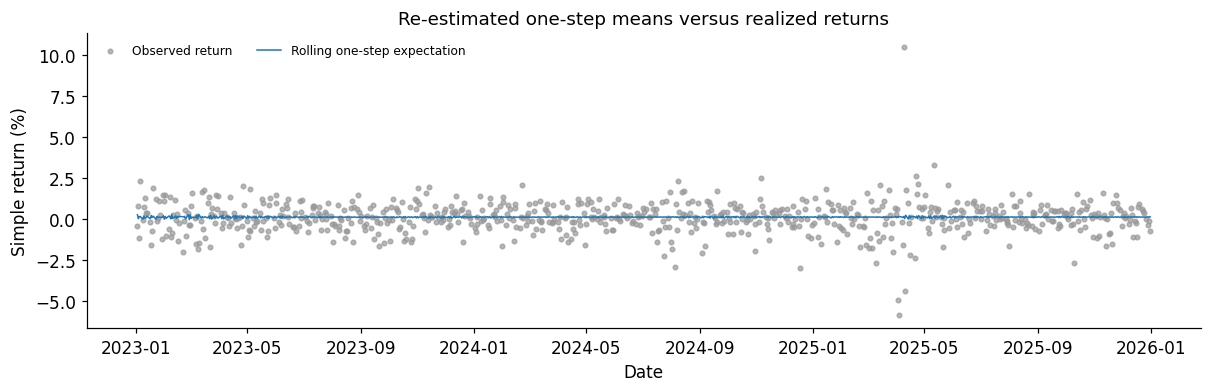

In [14]:
def report_refit_progress(done,total):
    if done%100==0 or done==total: print(f"Rolling refits: {done}/{total}",flush=True)

rolling_predictions = expanding_arma_garch_forecasts(
    returns.to_numpy(),final_fit,n_starts=2,seed=111,
    cache_path=repository/"artifacts/notebook11/rolling_spy_forecasts.csv",
    progress=report_refit_progress)
rolling_predictions.index = test.index
assert len(rolling_predictions)==len(test)
assert np.array_equal(rolling_predictions.target_index,np.arange(len(train),len(returns)))
assert (rolling_predictions.converged_starts>=1).all()
one_step_means = rolling_predictions["mean"].to_numpy()
one_step_variances = rolling_predictions["variance"].to_numpy()
actual = test.to_numpy()
errors = actual-one_step_means
rolling_mean_evaluation = pd.DataFrame([{"Model":"Rolling refit ARMA–GARCH",
    "ME (%)":errors.mean(),"RMSE (%)":forecast_rmse(actual,one_step_means),
    "MAE (%)":forecast_mae(actual,one_step_means)}]).set_index("Model")
display(rolling_mean_evaluation.round(4))
fig, ax = plt.subplots(figsize=(11,3.7))
ax.scatter(test.index,actual,color="0.6",s=9,alpha=.7,label="Observed return")
ax.plot(test.index,one_step_means,color="C0",linewidth=1,label="Rolling one-step expectation")
ax.set(xlabel="Date",ylabel="Simple return (%)",title="Re-estimated one-step means versus realized returns")
ax.legend(fontsize=8,ncol=2);fig.tight_layout();plt.show()

#### Downside Risk

Use each origin’s refitted Student-t degrees of freedom, mean and conditional SD for its 5% loss VaR and ES. Parameters are refitted each period, exactly as for the mean forecast. The highlighted points exceed that day’s VaR prediction.

VaR evaluation compares the exceedance percentage with 5%. For ES, compare realized loss on exceedance days with predicted ES averaged over those same days. This is a descriptive tail-severity check, not a formal ES backtest. The next subsection quantifies differences from Notebook 05’s fixed univariate descriptions.

The variance panel compares one-step conditional innovation variance with each refit’s implied unconditional innovation variance, $\omega/(1-\sum\alpha-\sum\beta)$. These are variance quantities in squared percentage-point units, not squared realized returns. The unconditional value treats each origin’s parameters as fixed indefinitely; near-unit persistence makes this extrapolation unstable. It is not the unconditional variance of the ARMA return level.

,Exceedances,Exceedance (%),Target (%),Realized tail loss (%),Predicted ES on exceedance days (%)
Rolling refit ARMA–GARCH,53,7.048,5.0,1.721,1.699


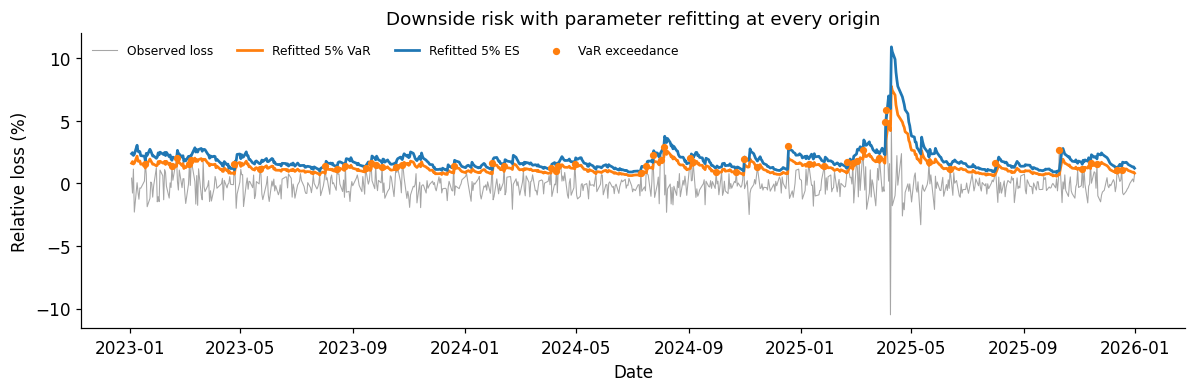

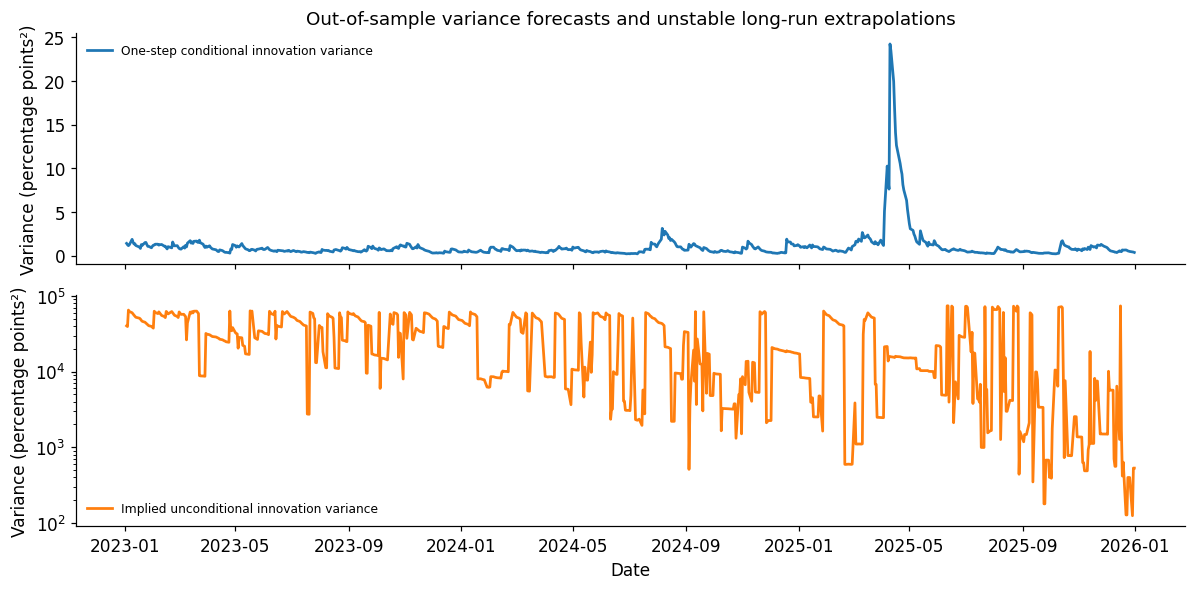

Near-unit persistence makes the implied unconditional variance highly unstable; the lower panel uses a logarithmic scale.


In [15]:
losses = -actual
conditional_risk = rolling_predictions[["VaR","ES"]].to_numpy()
conditional_exceed = losses>conditional_risk[:,0]
conditional_risk_summary = {
    "Exceedances":int(conditional_exceed.sum()),"Exceedance (%)":100*conditional_exceed.mean(),
    "Target (%)":5.,"Realized tail loss (%)":losses[conditional_exceed].mean(),
    "Predicted ES on exceedance days (%)":conditional_risk[conditional_exceed,1].mean()}
display(pd.DataFrame([conditional_risk_summary],index=["Rolling refit ARMA–GARCH"]).round(3))
fig, ax = plt.subplots(figsize=(11,3.7))
ax.plot(test.index,losses,color="0.65",linewidth=.7,label="Observed loss")
ax.plot(test.index,conditional_risk[:,0],color="C1",label="Refitted 5% VaR")
ax.plot(test.index,conditional_risk[:,1],color="C0",label="Refitted 5% ES")
ax.scatter(test.index[conditional_exceed],losses[conditional_exceed],color="C1",s=14,
           label="VaR exceedance",zorder=3)
ax.set(xlabel="Date",ylabel="Relative loss (%)",title="Downside risk with parameter refitting at every origin")
ax.legend(fontsize=8,ncol=4);fig.tight_layout();plt.show()
# Implied long-run innovation variance from each forecast-origin fit.
import json
rolling_omega = np.array([json.loads(p)["omega"] for p in rolling_predictions.parameters])
unconditional_innovation_variance = rolling_omega/(1-rolling_predictions.persistence.to_numpy())
fig, axes = plt.subplots(2,1,figsize=(11,5.5),sharex=True)
axes[0].plot(test.index,one_step_variances,color="C0",label="One-step conditional innovation variance")
axes[1].plot(test.index,unconditional_innovation_variance,color="C1",label="Implied unconditional innovation variance")
axes[1].set_yscale("log")
for ax in axes:
    ax.set_ylabel("Variance (percentage points²)")
    ax.legend(fontsize=8)
axes[0].set_title("Out-of-sample variance forecasts and unstable long-run extrapolations")
axes[1].set_xlabel("Date")
fig.tight_layout();plt.show()
print("Near-unit persistence makes the implied unconditional variance highly unstable; the lower panel uses a logarithmic scale.")

### Comparison with the Fixed Distribution Models

Use only Notebook 05’s univariate SPY descriptions: the empirical training distribution and fitted Student-t distribution. Recreate them using the same library functions, 2017–2022 returns, simple-return loss definition and 2023–2025 evaluation observations. Both baselines remain fixed, as they did in Notebook 05; no bond or joint-distribution result enters this comparison.

The mean table reports ME, RMSE and MAE on the same 752 target observations. RMSE/MAE reduction is positive when the rolling model improves on the fixed Student-t baseline. For risk, compare exceedance frequency and its absolute distance from 5%, then examine tail severity. Because thresholds select different days, ES gaps are not a common formal accuracy score.

This comparison assesses the complete forecasting procedures: the conditional model also receives parameter updates, so differences cannot be attributed solely to volatility dynamics.

In [16]:
baseline_fit = student_t.fit(train.to_numpy())
baseline_parameters = baseline_fit["params"]
baseline_mu,baseline_scale,baseline_df = (baseline_parameters[name] for name in ["mu","scale","df"])
empirical_mu = sample_mean(train)
fixed_var = student_t_var(-baseline_mu,baseline_scale,baseline_df,.05)
fixed_es = student_t_es(-baseline_mu,baseline_scale,baseline_df,.05)
empirical_var = historical_var(-train.to_numpy(),.05)
empirical_es = historical_es(-train.to_numpy(),.05)
mean_rows=[]
for label,mean in [("Fixed empirical (Notebook 05)",np.full(len(test),empirical_mu)),
                   ("Fixed Student-t (Notebook 05)",np.full(len(test),baseline_mu)),
                   ("Rolling refit ARMA–GARCH",one_step_means)]:
    mean_rows.append({"Model":label,"ME (%)":np.mean(actual-mean),
        "RMSE (%)":forecast_rmse(actual,mean),"MAE (%)":forecast_mae(actual,mean)})
mean_comparison_oos=pd.DataFrame(mean_rows).set_index("Model")
display(mean_comparison_oos.round(4))
risk_rows=[]
for label,var,es in [("Fixed empirical (Notebook 05)",np.full(len(test),empirical_var),np.full(len(test),empirical_es)),
                     ("Fixed Student-t (Notebook 05)",np.full(len(test),fixed_var),np.full(len(test),fixed_es)),
                     ("Rolling refit ARMA–GARCH",conditional_risk[:,0],conditional_risk[:,1])]:
    exceed=losses>var
    realized_es=losses[exceed].mean() if exceed.any() else np.nan
    predicted_es=es[exceed].mean() if exceed.any() else np.nan
    risk_rows.append({"Model":label,"Exceedances":int(exceed.sum()),"Exceedance (%)":100*exceed.mean(),
        "Distance from 5% (pp)":abs(100*exceed.mean()-5),
        "Realized tail loss (%)":realized_es,"Predicted ES on exceedance days (%)":predicted_es,
        "Tail severity gap (%)":realized_es-predicted_es})
risk_comparison_oos=pd.DataFrame(risk_rows).set_index("Model")
display(risk_comparison_oos.round(3))
fixed=mean_comparison_oos.loc["Fixed Student-t (Notebook 05)"]
rolling=mean_comparison_oos.loc["Rolling refit ARMA–GARCH"]
print(f"RMSE reduction versus fixed Student-t: {100*(1-rolling['RMSE (%)']/fixed['RMSE (%)']):.2f}%.")
print(f"MAE reduction versus fixed Student-t: {100*(1-rolling['MAE (%)']/fixed['MAE (%)']):.2f}%.")
fixed_gap=risk_comparison_oos.loc["Fixed Student-t (Notebook 05)","Distance from 5% (pp)"]
rolling_gap=risk_comparison_oos.loc["Rolling refit ARMA–GARCH","Distance from 5% (pp)"]
print(f"Reduction in absolute VaR frequency gap: {fixed_gap-rolling_gap:.2f} percentage points.")
print("Positive reductions mean improvement; negative values mean deterioration on that measure.")

,ME (%),RMSE (%),MAE (%)
Model,,,
Fixed empirical (Notebook 05),0.0369,0.9666,0.6550
Fixed Student-t (Notebook 05),-0.0107,0.9660,0.6535
Rolling refit ARMA–GARCH,-0.0225,0.9668,0.6546


,Exceedances,Exceedance (%),Distance from 5% (pp),Realized tail loss (%),Predicted ES on exceedance days (%),Tail severity gap (%)
Model,,,,,,
Fixed empirical (Notebook 05),13,1.729,3.271,3.029,3.152,-0.123
Fixed Student-t (Notebook 05),25,3.324,1.676,2.412,3.223,-0.811
Rolling refit ARMA–GARCH,53,7.048,2.048,1.721,1.699,0.023


RMSE reduction versus fixed Student-t: -0.09%.
MAE reduction versus fixed Student-t: -0.16%.
Reduction in absolute VaR frequency gap: -0.37 percentage points.
Positive reductions mean improvement; negative values mean deterioration on that measure.


The rolling refits do not improve mean prediction here: RMSE is 0.9668%, compared with 0.9660% for the fixed Student-t, and MAE is 0.6546% versus 0.6535%. The differences are small, consistent with weak predictability of daily signed returns.

Risk results are mixed. Rolling VaR is exceeded on 7.05% of days, versus 3.32% for the fixed Student-t and a 5% target. Its frequency is therefore 0.37 percentage points farther from the target; it understates risk on this measure, while the fixed Student-t is conservative. Rolling predicted ES averages 1.699% on its exceedance days, close to their realized mean loss of 1.721%. The fixed Student-t predicts 3.223% versus 2.412% realized on its own exceedance days. This closer conditional tail-severity alignment is descriptive, since the models select different tail observations.

The analysis therefore supports neither automatic improvement from refitting nor one overall winner. Time-varying risk estimates respond to history, but model calibration and future performance still require separate assessment.